# Phase Analyzer

Analyzes the phase patterns, modelled as genetic instances, after optimization 

In [12]:
# Functions to import

import numpy as np 
import scipy as sp
import pygad
import yaml 
from yaml import Loader 

from optical_functions import LG, propFF, cart2pol, oamModes, output_chan, setKnotType

import matplotlib.pyplot as plt 

from diffractsim import cm, mm, um 
import os

# Function which plots the phase and intensity of the field

'''
Jointly plots the intensity and phase patterns of the complex field.

Ex - complex 2D array -  field
'''

def TotInt(Ex):
    fig, ax =  plt.subplots(1,2,figsize=(10,10))
    ax[0].set_title('Intensity')
    intensity = ax[0].imshow(abs(Ex)**2,cmap="gist_gray")
    ax[0].axis('off')
    cbar=fig.colorbar(intensity, ax=ax[0])
    
    ax[1].set_title('Phase')
    phase = ax[1].imshow(np.angle(Ex), cmap="hsv", interpolation='nearest')
    ax[1].axis('off')
    cbar=fig.colorbar(phase, ax=ax[1])
    plt.show()


# Create field & modes of interest following yaml configuration

In [13]:
stream = open(f"configs/ga_knots.yaml", 'r')
cnfg = yaml.load(stream, Loader=Loader)

N = cnfg['dim']
num_of_output_chans = cnfg['num_output_chans']
output_chan_width = cnfg['output_chan_width'] * mm # in mm 

# Some parameters specifying the LG modes

LG_modes = cnfg['LG_modes']
w0 = cnfg['w0'] * mm # in mm!!

isKnot = cnfg['isKnot']
knotType = cnfg['knotType']
shapeParams = cnfg['shapeParams']

fourier_lens = cnfg['fourier_length']*cm # fourier length of both lens in cm

# Define the coordinate space 

la = 0.5*um
k=(2*np.pi)/la  # [m^-1] wavenumber    
maxx = 1.5 * mm # Full length of the numerical window (m)
N=128 # [Number of points per dimension]

# Space definition 
dx = maxx/N
dy = maxx/N 

#okay let's just say h here is dx or dy for now WLOG (WITH ... loss of generality)
h = dx

X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

xx,yy=np.meshgrid(X,Y);
r, phi= cart2pol(xx,yy)


''' 
Create the OAM beams that we need to sort 
'''
# Now create a list containing 'oamMode' objects 

list_of_OAMs = []
output_chans = output_chan(X,Y,output_chan_width,maxx,num_of_output_chans)

if(isKnot):
    for ii in range(len(knotType)):
        list_of_OAMs.append(oamModes(setKnotType(r, phi, w0, knotType[ii], shapeParams[ii]), output_chans[ii]))
        
else:
    for ii in range(len(LG_modes)):
        list_of_OAMs.append(oamModes(LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k), output_chans[ii]))


Load genetic instance

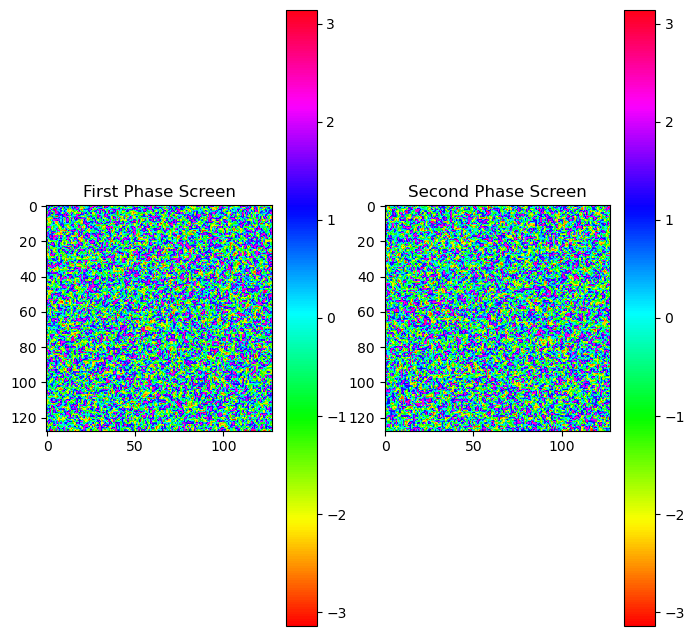

In [14]:
import pickle

instance_name = 'oam_knots'

with open(f"best_phases/{instance_name}.pkl", 'rb') as file:
     phase_out = pickle.load(file)
        
# Compute phase screens and plot them 
phaseScreenUno = np.exp(1j*phase_out[0,:,:])
phaseScreenDos = np.exp(1j*phase_out[1,:,:])

fig, ax = plt.subplots(1,2, figsize=(8,8))

first = ax[0].imshow(np.angle(phaseScreenUno), cmap='hsv')
ax[0].set_title("First Phase Screen")
c1 = fig.colorbar(first, ax=ax[0])


second = ax[1].imshow(np.angle(phaseScreenDos), cmap='hsv')
ax[1].set_title("Second Phase Screen")
c2 = fig.colorbar(second, ax=ax[1])

plt.show()

Compute the propagation for each mode

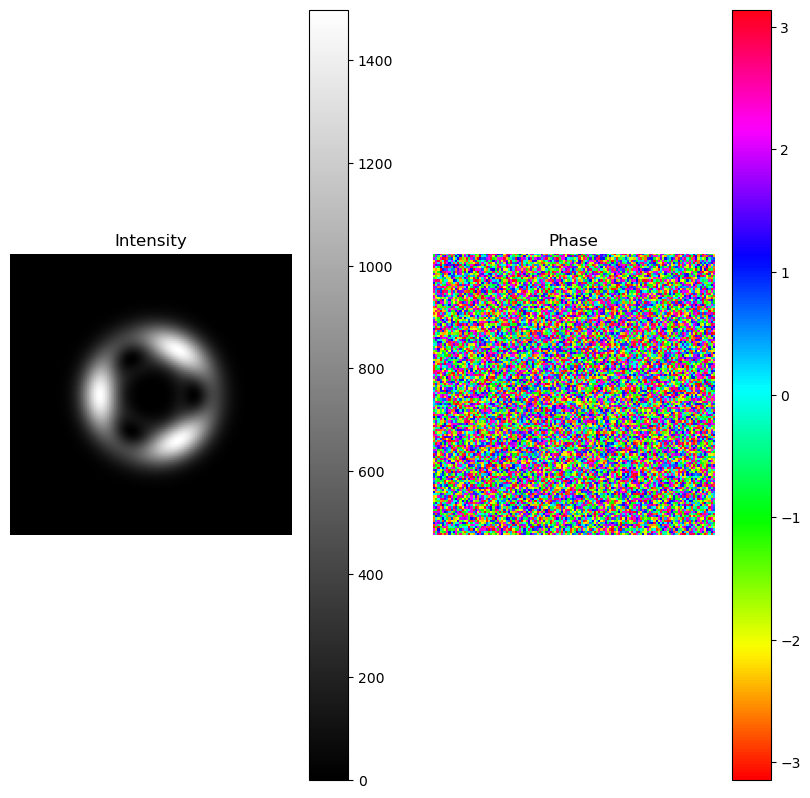

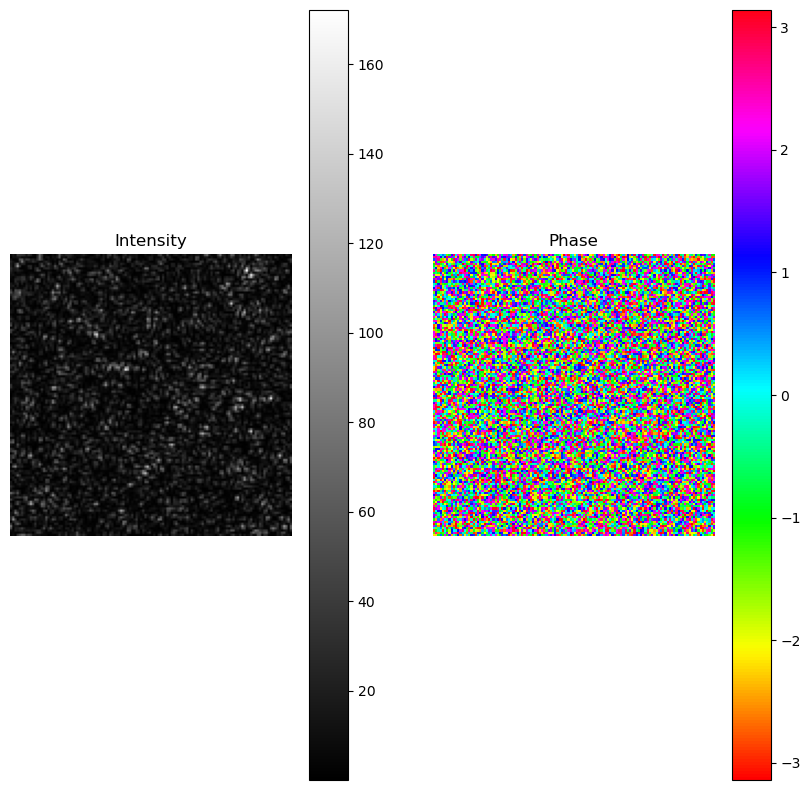

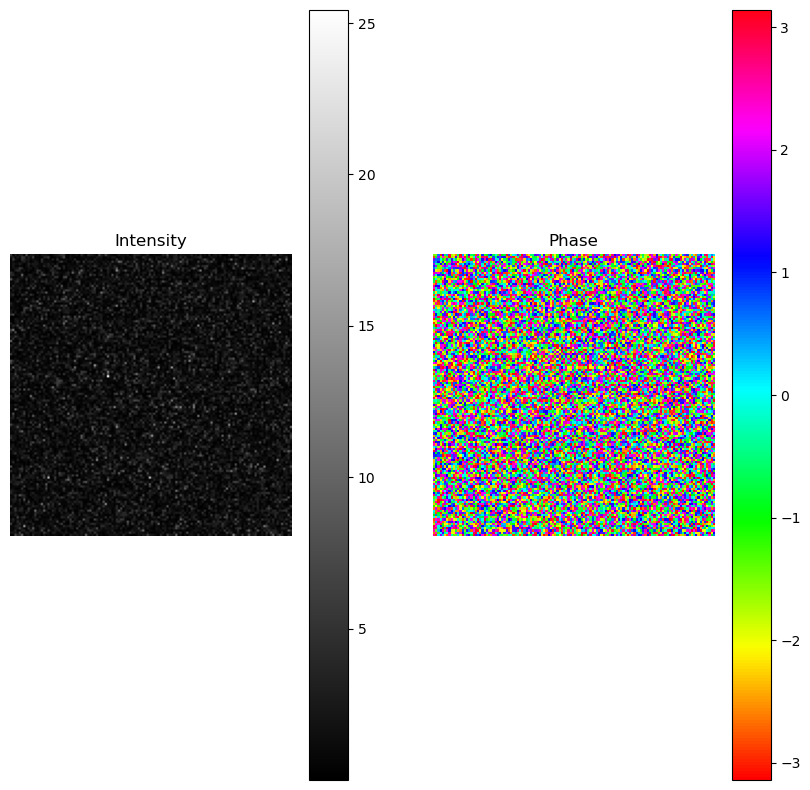

In [15]:
# Let's pick an LG beam to analyze

field = list_of_OAMs[0].oamBeam 


# modulate the field by the first phase map 

field_mod_1 = field*phaseScreenUno

TotInt(field_mod_1)

# let's simulate the propagation of the lens

field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)

# modulate the field by the second phase map 

field_mod_2 = field_lens*phaseScreenDos

TotInt(field_mod_2)

# simulate the lens field again. This is the final field. 

field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)


TotInt(field_lens_2)

# compute the field intensity 

final_field_int = np.abs(field_lens_2)**2